# Testing Leo against ion acoustic wave Landau damping

Commit a460d129

A quasi-1-dimensional box is initialised with a density profile taken as 5 spatial periods of a sinus, of amplitude 0.05 of the average density.

In [1]:
from menura_utils import *
import own_tools as oT
import own_colours as oC
path = '../menura'

In [2]:
mp = menura_param(f'{path}/products')
mp.print_physical_parameters()
mg = menura_grid(f'{path}/products', mp)


._____________________________________________________________________________________
| Physical run parameters:
|    
| 1 process.
|
| B_0:                              1.80e-09 T
| n_0:                              5.00e+06 m^-3
| T_eon:                            1.00e+05 K
| T_ion:                            1.50e+04 K
|
| Proton plasma frequency:         2943.9300 rad/s
| Proton gyrofrequency:               0.1724 rad/s
| Electron plasma frequency:       1.2616e+05 rad/s
| Electron gyrofrequency:           316.5660 rad/s
|
| Proton inertial length d_i :      101.8340 km
| Electron inertial length d_e :      2.3762 km
| Debye length lambda_D :             0.0098 km
| Gyro-radius (v_th) :                0.8963
|
| Alfven speed :                     17.5538 km/s
| Sound speed :                      34.5915 km/s
| Magnetosonic speed :               38.7906 km/s
| Ion thermal speed :                15.7343 km/s
| Electron thermal speed :         1741.0600 km/s
|
| Beta_p :           

The wavelength is fixed by the box size and fed to WHAMP, obtaining a phase velocity almost equal to the speed of sound, as shown by the white circle in the right-hand plot below, matching the simulated wave.

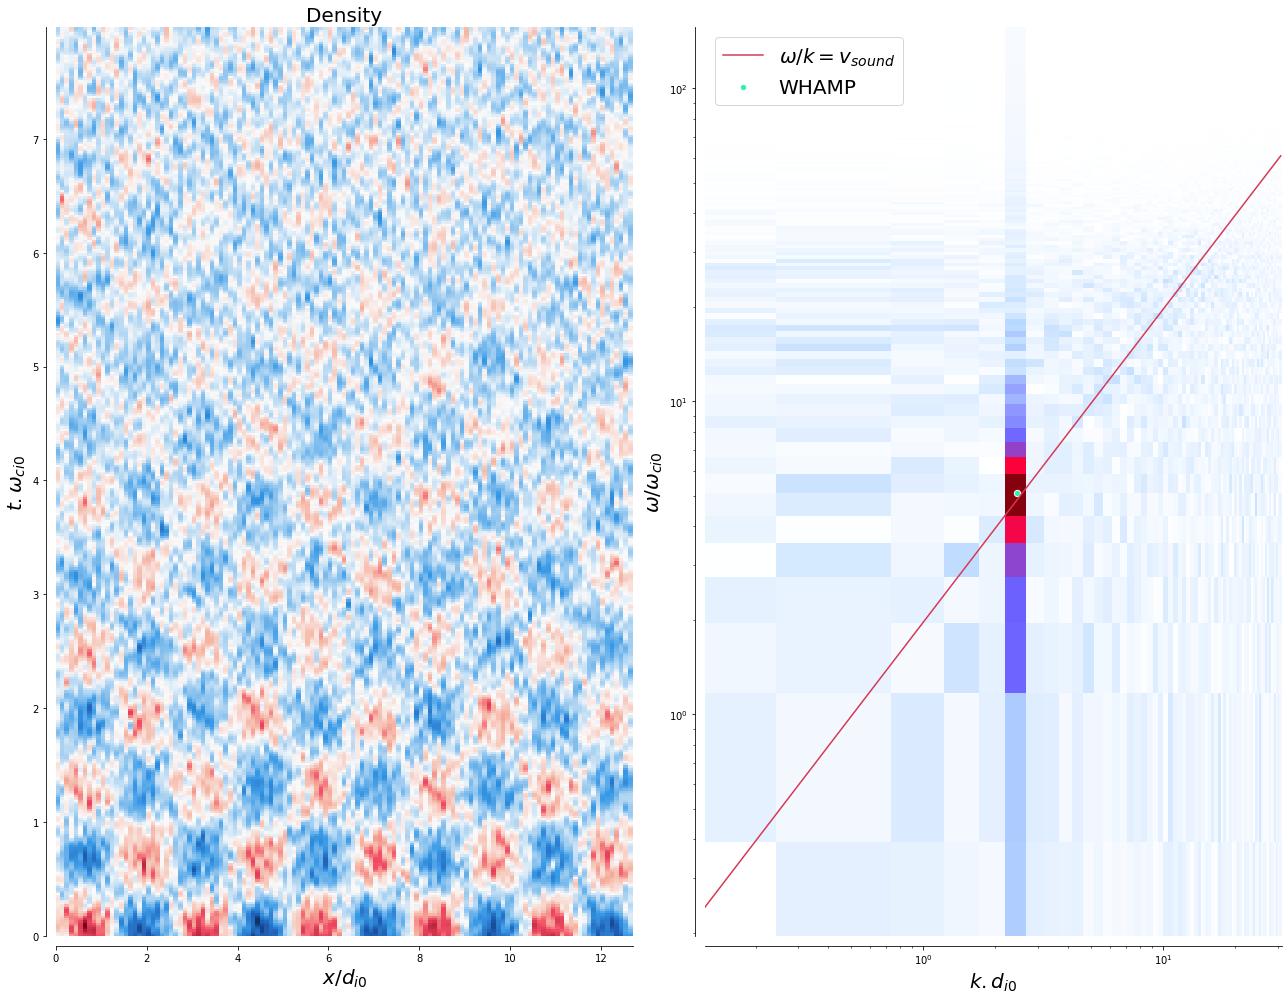

In [3]:
dens_t_s = np.load(f'{path}/products/dens_time_space_rank0.npy')
field_omega_k_spectrum((dens_t_s-np.mean(dens_t_s)), 'Density', mp.dt_low, mp.dx_low, mp, loglog=True, disp_rel='acoustic')

The wave is seen to be damped. We plot now the time evolution of the density at the simulation nodes. The exponential envelop is taken using the WHAMP damping rate.

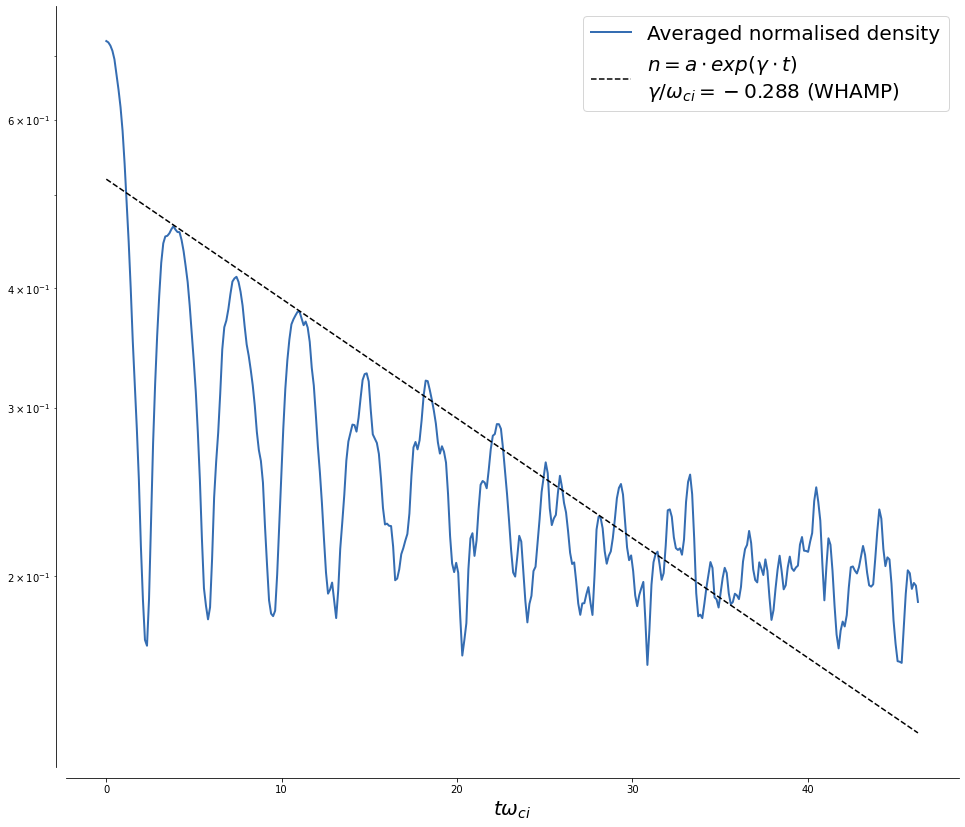

In [6]:
grid_t_low = np.arange(dens_t_s.shape[0])*mp.dt_low

grid_t_low /= mp.omega_ci
gamma = -.0288#*1.2
a = .52#.034#.59

fig, ax = plt.subplots(figsize=(16, 14))

d = np.abs(dens_t_s-1)
d -= np.amin(d, axis=0)
d /= np.amax(d, axis=0)
ax.plot(grid_t_low, np.nanmean(d, axis=1), c=oC.rgb[2], lw=2, label='Averaged normalised density')
ax.plot(grid_t_low, a*np.exp(gamma*grid_t_low), '--k', label='$n = a\cdot exp(\gamma\cdot t)$\n$\gamma/\omega_{ci}=-0.288$ (WHAMP)')



ax.set_xlabel('$t\omega_{ci}$', fontsize=20)
ax.set_yscale('log')
ax.legend(fontsize=20)
oT.set_spines(ax)
plt.savefig('landau.pdf')
plt.show()

We now look at the signature of this damping on the particle velocity distribution function, identifying the Landau resonant particles around the phase speed of the wave.

In [7]:
from scipy.optimize import curve_fit
def maxwellian_1D(v, A, v_th, v0):
    return A * np.exp(-((v-v0)/v_th)**2)

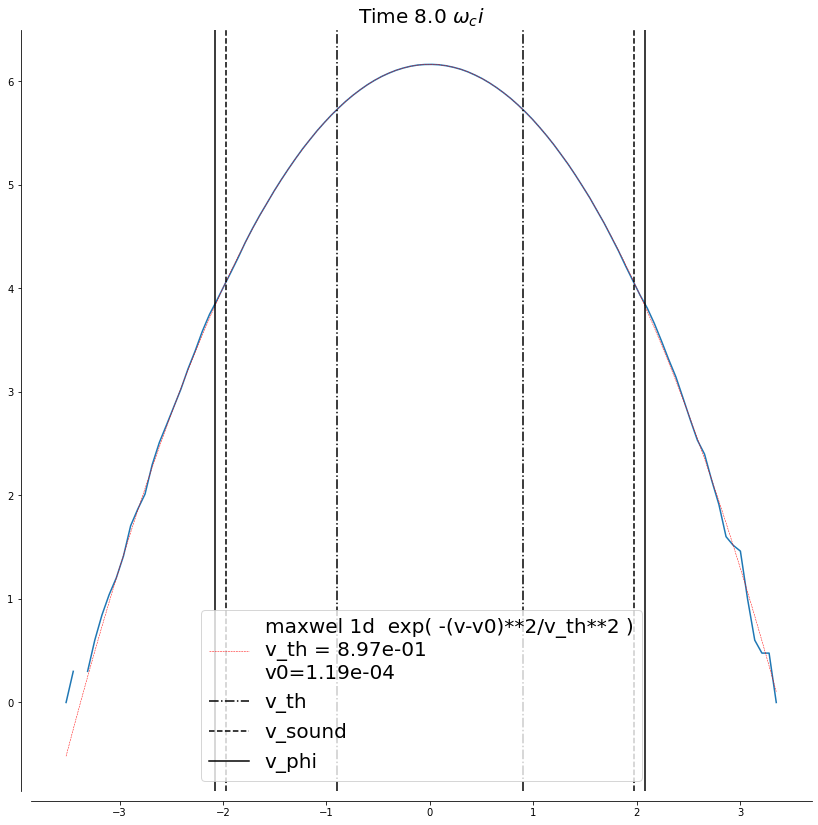

In [8]:
ind_it = 4000
p = np.load(f'{path}/products/particles_0_it{ind_it}_rank0.npy').astype(np.float32).T

h_vx, bin_vx = np.histogram(p[2], 100)
centers_vx = .5*(bin_vx[:-1]+bin_vx[1:])

p0 = [np.amax(h_vx), np.var(p[2]), np.average(centers_vx, weights=h_vx)]
p_m, pcov = curve_fit(maxwellian_1D, centers_vx, h_vx)
    
fig, ax = plt.subplots(figsize=(14, 14))
    
ax.plot(centers_vx, np.log10(h_vx))#bins)
ax.plot(centers_vx, np.log10(maxwellian_1D(centers_vx, *p_m)),
        '--r', lw=.5, label=f'maxwel 1d  exp( -(v-v0)**2/v_th**2 )\nv_th = {p_m[1]:.2e}\nv0={p_m[2]:.2e}')
v_phi = 5.108/2.454
p_m[1]
ax.axvline(p_m[1], ls='dashdot', c='k')
ax.axvline(-p_m[1], ls='dashdot', c='k', label='v_th')
ax.axvline(mp.v_s/mp.v_A, ls='--', c='k')
ax.axvline(-mp.v_s/mp.v_A, ls='--', c='k', label='v_sound')
ax.axvline(v_phi, c='k')
ax.axvline(-v_phi, c='k', label='v_phi')
ax.legend(fontsize=20)
    
plt.title(f'Time {ind_it*mp.dt} $\omega_ci$', fontsize=20)
oT.set_spines(ax)
plt.show()

## Non-non-linear interaction

If we now increase the initial perturbation amplitude to 0.05 the background density:

In [ ]:
mp = menura_param(f'{path}/products')
mp.print_physical_parameters()
mg = menura_grid(f'{path}/products', mp)

In [ ]:
dens_t_s = np.load(f'{path}/products/dens_time_space_rank0.npy')
field_omega_k_spectrum((dens_t_s-np.mean(dens_t_s)), 'Density', mp.dt_low, mp.dx_low, mp, loglog=True, disp_rel='acoustic')

In [ ]:
grid_t_low = np.arange(dens_t_s.shape[0])*mp.dt_low

grid_t_low /= mp.omega_ci
gamma = -.0288#*np.sqrt(2)
a = .56#.034

fig, ax = plt.subplots(figsize=(16, 14))

d = np.abs(dens_t_s-1)
d -= np.amin(d, axis=0)
d /= np.amax(d, axis=0)
ax.plot(grid_t_low, np.nanmean(d, axis=1), c=oC.rgb[2], lw=2, label='Averaged normalised density')
ax.plot(grid_t_low, a*np.exp(gamma*grid_t_low), '--k', label='$n = a\cdot exp(\gamma\cdot t)$\n$\gamma/\omega_{ci}=-0.288$ (WHAMP)')

ax.set_xlabel('$t\omega_{ci}$', fontsize=20)
ax.set_yscale('log')
ax.legend(fontsize=20)
oT.set_spines(ax)
plt.savefig('landau.pdf')
plt.show()

In [ ]:
ind_it = 4000
p = np.load(f'{path}/products_landau/particles_0_{ind}_rank0.npy').astype(np.float32).T

h_vx, bin_vx = np.histogram(p[2], 100)
centers_vx = .5*(bin_vx[:-1]+bin_vx[1:])

p0 = [np.amax(h_vx), np.var(p[2]), np.average(centers_vx, weights=h_vx)]
p_m, pcov = curve_fit(maxwellian_1D, centers_vx, h_vx)
    
fig, ax = plt.subplots(figsize=(14, 14))
    
ax.plot(centers_vx, np.log10(h_vx))#bins)
ax.plot(centers_vx, np.log10(maxwellian_1D(centers_vx, *p_m)),
        '--r', lw=.5, label=f'maxwel 1d  exp( -(v-v0)**2/v_th**2 )\nv_th = {p_m[1]:.2e}\nv0={p_m[2]:.2e}')
v_phi = 5.108/2.454
p_m[1]
ax.axvline(p_m[1], ls='dashdot', c='k')
ax.axvline(-p_m[1], ls='dashdot', c='k', label='v_th')
ax.axvline(lp.v_s/lp.v_A, ls='--', c='k')
ax.axvline(-lp.v_s/lp.v_A, ls='--', c='k', label='v_sound')
ax.axvline(v_phi, c='k')
ax.axvline(-v_phi, c='k', label='v_phi')
ax.legend(fontsize=20)
    
plt.title(f'Time {ind*lp.dt} $\omega_ci$', fontsize=20)
oT.set_spines(ax)
plt.show()